kMeans - yêu cầu cụm dữ liệu có tương tác tuyến tính.
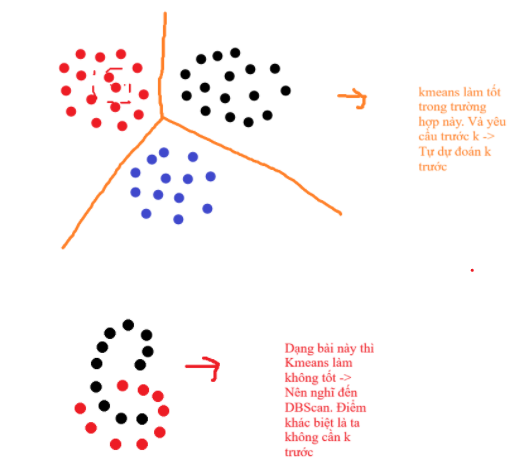

Ví dụ 1

In [ ]:
from __future__ import absolute_import, division, print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(11)

# Kỳ vọng và hiệp phương sai của 3 cụm dữ liệu
means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]

# Số điểm mỗi cụm dữ liệu
N = 500

# Tạo các cụm dữ liệu qua phân bố chuẩn (Gaussian)
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

# Tổng hợp dữ liệu từ các cụm
X = np.concatenate((X0, X1, X2), axis = 0)

# Số cụm = 3
K = 3

# Gán nhãn ban đầu cho các cụm, sau đó test model và so sánh
original_label = np.asarray([0]*N + []*N + [2]*N).T

In [ ]:
# Hiển thị dữ liệu X lên mặt phẳng
def kmeans_display(X, label):
  K = np.amax(label) + 1
  X0 = X[label == 0,:]
  X1 = X[label == 1,:]
  X2 = X[label == 2,:]

  plt.plot(X0[:, 0], X0[:, 1], 'b^', markersize = 4, alpha = .8)
  plt.plot(X1[:, 0], X1[:, 1], 'go', markersize = 4, alpha = .8)
  plt.plot(X2[:, 0], X2[:, 1], 'rs', markersize = 4, alpha = .8)

  plt.axis('equal')
  plt.plot()
  plt.show()

In [ ]:
def kmeans_init_centers(X, k):
  return X[np.random.choice(X.shape[0], k, replace=False)]

In [ ]:
# Gán cụm cho 1 điểm dữ liệu bằng cách tính khoảng cách từ điểm đó đến tâm cụm
def kmeans_assign_labels(X, centers):
  D = cdist(X, centers)
  return np.argmin(D, axis = 1)

In [ ]:
# Phương thức cập nhật lại tâm cụm sau mỗi bước lặp
def kmeans_update_centers(X, labels, K):
  centers = np.zeros((K, X.shape[1]))
  for k in range(K):
    Xk = X[labels == k, :]
    centers[k, :] = np.mean(Xk, axis = 0)
  return centers

In [ ]:
def has_converged(centers, new_centers):
  return (set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers]))

In [ ]:
# Vòng lặp thực hiện tất cả các bước trong thuật toán KMeans cho đến khi thuật toán dừng
def kmeans(X, K):
  centers = [kmeans_init_centers(X, K)]
  labels = []
  it = 0
  while True:
    labels.append(kmeans_assign_labels(X, centers[-1]))
    new_centers = kmeans_update_centers(X, labels[-1], K)
    if has_converged(centers[-1], new_centers):
      break
    centers.append(new_centers)
    it += 1
  return (centers, labels, it)

Centers found by our algorithm:
[[2.99084705 6.04196062]
 [1.97563391 2.01568065]
 [8.03643517 3.02468432]]


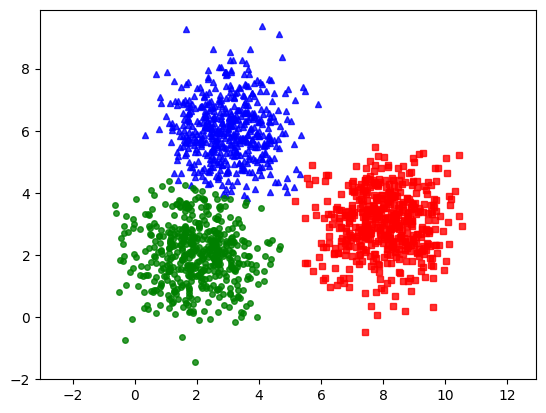

In [ ]:
#Gọi và thực hiện phương pháp
(centers, labels, it) = kmeans(X, K)
print("Centers found by our algorithm:")
print(centers[-1])
kmeans_display(X, labels[-1])

Thực hiện bằng thư viện sklearn

Centers found by scikit - learn: 
[[1.97826939 2.00223913]
 [2.98759958 6.02896527]
 [8.0410628  3.02094748]]


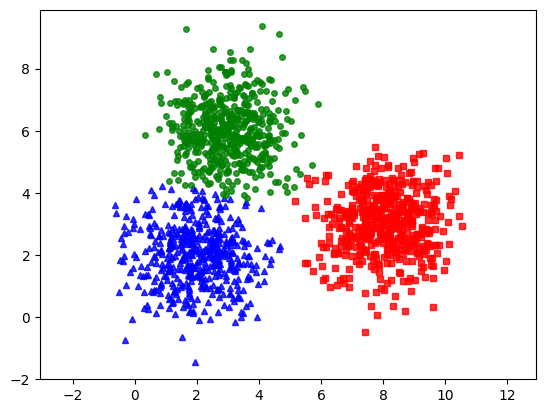

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters= 3, random_state= 0).fit(X)
print("Centers found by scikit - learn: ")
print(kmeans.cluster_centers_)
pred_label = kmeans.predict(X)
kmeans_display(X, pred_label)

Ví dụ 2: Thực hiện phân cụm cho bộ dữ liệu chữ số viết tay

In [ ]:
# Import các thư viện cần thiết
import numpy as np
from mnist import MNIST
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

In [ ]:
#pip install python-mnist
!pip install python-MNIST

In [ ]:
# Xây dựng phương thức hiển thị dữ liệu
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
def display_network(A, m = -1, n = -1):
  opt_normalize = True
  opt_graycolor = True

  A = A - np.average(A)
  (row, col) = A.shape
  sz = int(np.ceil(np.sqrt(row)))
  buf = 1
  if m < 0 or n < 0:
    n = np.ceil(np.sqrt(col))
    m = np.ceil(col/n)
  image = np.ones(shape = (buf + m * (sz + buf), buf + n*(sz + buf)))
  if not opt_graycolor:
    image *=0.1
  k = 0
  for i in range(int(m)):
    for j in range(int(n)):
      if k >= col:
        continue
      clim = np.max(np.abs(A[:, k]))
      if opt_normalize:
        image[buf + i*(sz + buf):buf + i*(sz + buf) + sz, buf + j*(sz + buf):buf + j*(sz + buf) + sz] =  A[:, k].np.reshape(sz, sz)/clim
      else:
        image[buf + i*(sz + buf):buf + i*(sz + buf) + sz, buf + j*(sz+buf):buf + j*(sz + buf) + sz] =  A[:, k].reshape(sz, sz) / np.max(np.abs(A))
      k +=1
  return image

def display_color_network(A):
  if np.min(A) >= 0:
    A = A - np.mean(A)
  cols = np.round(np.sqrt(A.shape[1]))
  channel_size = A.shape[0] / 3
  dim = np.sqrt(channel_size)
  dimp = dim + 1
  rows = np.ceil(A.shape[1] / cols)

  B = A[0: channel_size, :]
  C = A[channel_size: 2*channel_size, :]
  D = A[2*channel_size: 3*channel_size, :]

  B = B/ np.max(np.abs(B))
  C = C/ np.max(np.abs(C))
  D = D/ np.max(np.abs(D))

  image = np.ones(shape = (dim* rows + rows - 1, dim* cols + cols - 1, 3))
  for i in range(int(rows)):
    for j in range(int(cols)):
      image[i*dimp:i * dimp + dim, j*dimp: j*dimp + dim, 0] = B[:, i*cols + j].reshape(dim, dim)
      image[i*dimp:i * dimp + dim, j*dimp: j*dimp + dim, 1] = C[:, i*cols + j].reshape(dim, dim)
      image[i*dimp:i * dimp + dim, j*dimp: j*dimp + dim, 2] = D[:, i*cols + j].reshape(dim, dim)
  image = (image + 1)/2
  return image

In [ ]:
import gzip
import numpy as np
from sklearn.cluster import KMeans # Import KMeans as it's used later

with gzip.open('/content/train-labels-idx1-ubyte.gz', 'rb') as f:
  y = np.frombuffer(f.read(), np.uint8, offset = 8)
print(y.shape)
with gzip.open('/content/train-images-idx3-ubyte.gz', 'rb') as f:
  X_raw = np.frombuffer(f.read(), dtype=np.uint8, offset=16)

# Reshape the 1D array into a 2D array of images (each 28x28 pixels)
X_reshaped = X_raw.reshape(-1, 28 * 28)

X0 = np.asarray(X_reshaped)[:1000, :]/256.0
X = X0
K = 10
kmeans = KMeans(n_clusters = K, random_state=0).fit(X) # Added random_state for reproducibility
pred_label = kmeans.predict(X)

(60000,)


<class 'numpy.ndarray'>
(784, 10)


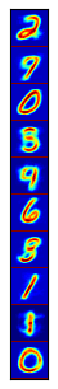

In [ ]:
# Hiển thị 1 số ảnh thuộc 1 số cụm
print(type(kmeans.cluster_centers_.T))
print(kmeans.cluster_centers_.T.shape)
A = display_network(kmeans.cluster_centers_.T, K, 1)

f1 = plt.imshow(A, interpolation= 'nearest', cmap = 'jet')
f1.axes.get_xaxis().set_visible(False)
f1.axes.get_yaxis().set_visible(False)
plt.show()

cmap = plt.cm.jet
norm = plt.Normalize(vmin = A.min(), vmax = A.max())
image = cmap(norm(A))
# import scipy.misc
# scipy.misc.imsave('aa.png', image)
N0 = 20
X1 = np.zeros((N0*K, 784))
X2 = np.zeros((N0*K, 784))
for k in range(K):
  Xk = X0[pred_label == k, :]
  center_k = [kmeans.cluster_centers_[k]]
  neigh = NearestNeighbors().fit(Xk)
  dist, nearest_id = neigh.kneighbors(center_k, N0)
  X1[N0*k:N0*(k+1), :] = Xk[nearest_id, :]
  X2[N0*k: N0*(k+1), :] = Xk[:N0, :]

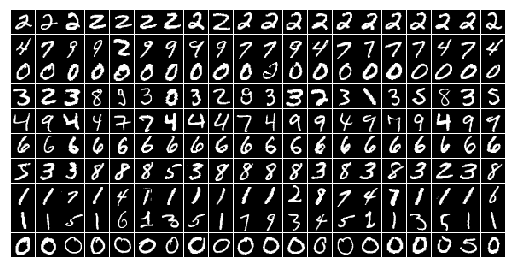

In [ ]:
# Hiển thị kết quả
plt.axis('off')
A = display_network(X2.T, K, N0)
f2 = plt.imshow(A, interpolation= 'nearest')
plt.gray()
plt.show()

Bài tập tự thực hành. Bài 1.1

In [3]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
#!pip install python-MNIST
#from mnist import MNIST
np.random.seed(11)
# Load dữ liệu
import gzip
import numpy as np
from sklearn.cluster import KMeans # Import KMeans as it's used later
with gzip.open('/content/train-labels-idx1-ubyte.gz', 'rb') as f:
  y = np.frombuffer(f.read(), np.uint8, offset = 8)
print(y.shape)
with gzip.open('/content/train-images-idx3-ubyte.gz', 'rb') as f:
  X = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
  X = X.reshape(-1, 784)
# Lấy 1000 mẫu đầu
X = X[:1000, :]/255.0
y = y[:1000]
K = 10

# K-means
def kmeans_init_centers(X, k):
  return X[np.random.choice(X.shape[0], k, replace = False)]

def kmeans_assign_labels(X, centers):
  D = cdist(X, centers)
  return np.argmin(D, axis = 1)

def kmeans_update_centers(X, labels, K):
  centers = np.zeros((K, X.shape[1]))
  for k in range(K):
    Xk = X[labels == k, :]
    if len(Xk) > 0:
      centers[k, :] = np.mean(Xk, axis = 0)
  return centers

def has_converged(centers, new_centers):
  return set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers])

def kmeans(X, K):
  centers = [kmeans_init_centers(X, K)]
  labels = []
  it = 0
  while True:
    labels.append(kmeans_assign_labels(X, centers[-1]))
    new_centers = kmeans_update_centers(X, labels[-1], K)
    if has_converged(centers[-1], new_centers):
      break
    centers.append(new_centers)
    it +=1
  return (centers, labels, it)

(centers, labels, it) = kmeans(X, K)
print("Số lần lặp: ", it)
print("Centers shape: ", centers[-1].shape)

(60000,)
Số lần lặp:  16
Centers shape:  (10, 784)


In [ ]:
# Kiểm tra độ chính xác của cụm
for k in range(K):
    cluster_labels = y[labels[-1] == k]
    if len(cluster_labels) == 0:
        continue

    counts = np.bincount(cluster_labels)
    dominant = np.argmax(counts)
    accuracy = counts[dominant] / len(cluster_labels)

    print(f"Cluster {k}: digit {dominant}, accuracy = {accuracy:.2f}")

Cluster 0: digit 8, accuracy = 0.80
Cluster 1: digit 0, accuracy = 0.86
Cluster 2: digit 4, accuracy = 0.34
Cluster 3: digit 7, accuracy = 0.53
Cluster 4: digit 0, accuracy = 0.83
Cluster 5: digit 1, accuracy = 0.64
Cluster 6: digit 6, accuracy = 0.86
Cluster 7: digit 3, accuracy = 0.59
Cluster 8: digit 2, accuracy = 1.00
Cluster 9: digit 5, accuracy = 0.36


Bài tập tự thực hành. Bài 1.2

In [9]:
!unzip /content/cats_and_dogs_filtered.zip -d /content/

Archive:  /content/cats_and_dogs_filtered.zip
   creating: /content/cats_and_dogs_filtered/
  inflating: /content/cats_and_dogs_filtered/vectorize.py  
   creating: /content/cats_and_dogs_filtered/validation/
   creating: /content/cats_and_dogs_filtered/train/
   creating: /content/cats_and_dogs_filtered/validation/dogs/
  inflating: /content/cats_and_dogs_filtered/validation/dogs/dog.2127.jpg  
  inflating: /content/cats_and_dogs_filtered/validation/dogs/dog.2126.jpg  
  inflating: /content/cats_and_dogs_filtered/validation/dogs/dog.2125.jpg  
  inflating: /content/cats_and_dogs_filtered/validation/dogs/dog.2124.jpg  
  inflating: /content/cats_and_dogs_filtered/validation/dogs/dog.2123.jpg  
  inflating: /content/cats_and_dogs_filtered/validation/dogs/dog.2122.jpg  
  inflating: /content/cats_and_dogs_filtered/validation/dogs/dog.2121.jpg  
  inflating: /content/cats_and_dogs_filtered/validation/dogs/dog.2120.jpg  
  inflating: /content/cats_and_dogs_filtered/validation/dogs/dog.2119

In [11]:
import os
import cv2
import numpy as np
from sklearn.cluster import KMeans

data_dir = "/content/cats_and_dogs_filtered/train" # Corrected path

X = []
y = []
IMG_SIZE = 64

for label, folder in enumerate(["cats", "dogs"]):
    path = os.path.join(data_dir, folder)

    for img_name in os.listdir(path)[:500]:
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img.flatten())
        y.append(label)

X = np.array(X) / 255.0
y = np.array(y)

print("Shape:", X.shape)

# K-means
K = 2
kmeans = KMeans(n_clusters=K, random_state=0)
pred = kmeans.fit_predict(X)

# Đánh giá
from scipy.stats import mode

labels = np.zeros_like(pred)

for i in range(K):
    mask = (pred == i)
    if np.sum(mask) == 0:
        continue
    labels[mask] = mode(y[mask], keepdims=True)[0]

accuracy = np.mean(labels == y)
print("Accuracy:", accuracy)

Shape: (1000, 12288)
Accuracy: 0.532


Ví dụ 2.1

In [49]:
import numpy as np
import matplotlib.pyplot as plt # Needed for the plot method

# Xây dựng class DBScan, đầu vào là epsilon, minppts, dữ liệu đầu vào cần phân cụm là input
class DBSCAN(object):
  def __init__(self, x, epsilon, minpts):
    self.n = len(x)
    p, q = np.meshgrid(np.arange(self.n), np.arange(self.n))
    self.dist = np.sqrt(np.sum(((x[p] - x[q])**2), 2))
    self.visited = np.full((self.n), False)
    self.noise = np.full((self.n), False)
    self.epsilon = epsilon
    self.minpts = minpts
    self.idx = np.full((self.n), 0)
    self.C = 0
    self.input = x

  # regionQuery method (originally from HQ2EDlatRF3Z)
  def regionQuery(self, i):
    g = self.dist[i, :] < self.epsilon
    Neighbors = np.where(g)[0].tolist()
    return Neighbors

  # expandCluster method (originally from 6HdbdQcjRaQz)
  def expandCluster(self, i):
    self.idx[i] = self.C
    k = 0
    while True:
      if len(self.neighbors) <= k: return
      j = self.neighbors[k]
      if self.visited[j] != True:
        self.visited[j] = True
        self.neighbors2 = self.regionQuery(j)
        v = [self.neighbors2[l] for l in np.where(self.idx[self.neighbors2]==0)[0]]
        if len(self.neighbors2) >= self.minpts:
          self.neighbors.extend(v) # Use extend for lists
      if self.idx[j] == 0 : self.idx[j] = self.C
      k +=1

  # run method (consolidated and corrected)
  def run(self):
    for i in range(self.n):
      if self.visited[i]: continue
      self.visited[i] = True
      self.neighbors = self.regionQuery(i)
      if len(self.neighbors) < self.minpts:
        self.noise[i] = True
      else:
        self.C += 1
        self.expandCluster(i)
    return self.idx, self.noise

  # sort method (originally from JyqBL3HjWaZf)
  def sort(self):
    cnum = np.max(self.idx)
    self.cluster = []
    self.noise = []
    for i in range(cnum):
      k = np.where(self.idx == (i+1))[0].tolist()
      self.cluster.append([self.input[k,:]])
    self.noise = self.input[np.where(self.idx == 0)[0].tolist(),:]
    return self.cluster, self.noise

  # plot method (originally from JyqBL3HjWaZf)
  def plot(self):
    self.sort()
    fig,ax = plt.subplots()
    for idx,group in enumerate(self.cluster):
      ax.plot(group[0][:,0], group[0][:,1], marker='o', linestyle='', label='Cluster {}'.format(idx))
    if self.noise.shape[0] > 0: # Check if there are any noise points
      ax.plot(self.noise[:,0], self.noise[:,1], marker='x', linestyle='', label='noise')
    ax.legend(fontsize=10, loc='upper left')
    plt.title('Scatter Plot of Clustering result', fontsize=15)
    plt.xlabel('X', fontsize=14)
    plt.ylabel('Y', fontsize=14)
    plt.show()

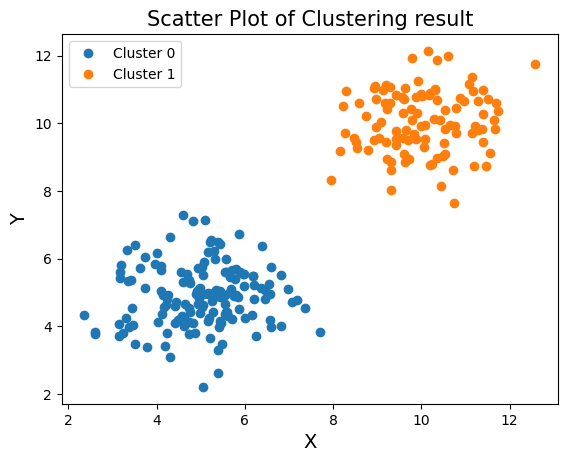

In [51]:
from scipy import io
import pandas as pd

# Load data
df = pd.read_csv('/content/input.csv')
x = np.zeros([len(df), 2], float )
x[:, 0] = np.array(df['x1'], float)
x[:, 1] = np.array(df['x2'], float)
#%% Run DEMO
# INIT DBSCAN
dbscan = DBSCAN(x,1.5,4)
# CLUSTERING
idx,noise = dbscan.run()
# SORTING
g_cluster,n_cluster = dbscan.sort()
# Visualization
dbscan.plot()

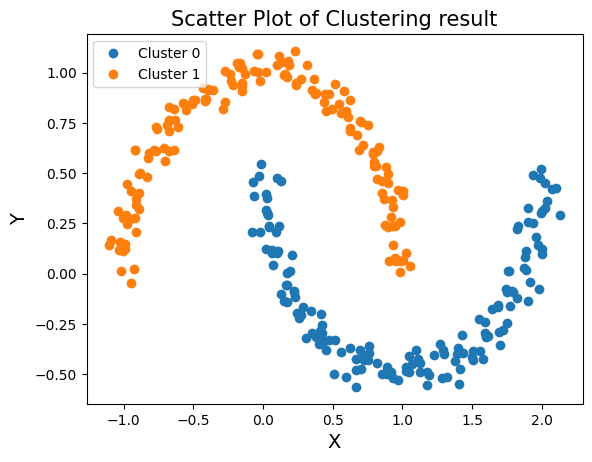

In [53]:
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# INIT DBSCAN
dbscan = DBSCAN(X, 0.3, 5)
# CLUSTERING
idx,noise = dbscan.run()
# SORTING
g_cluster,n_cluster = dbscan.sort()
# Visualization
dbscan.plot()

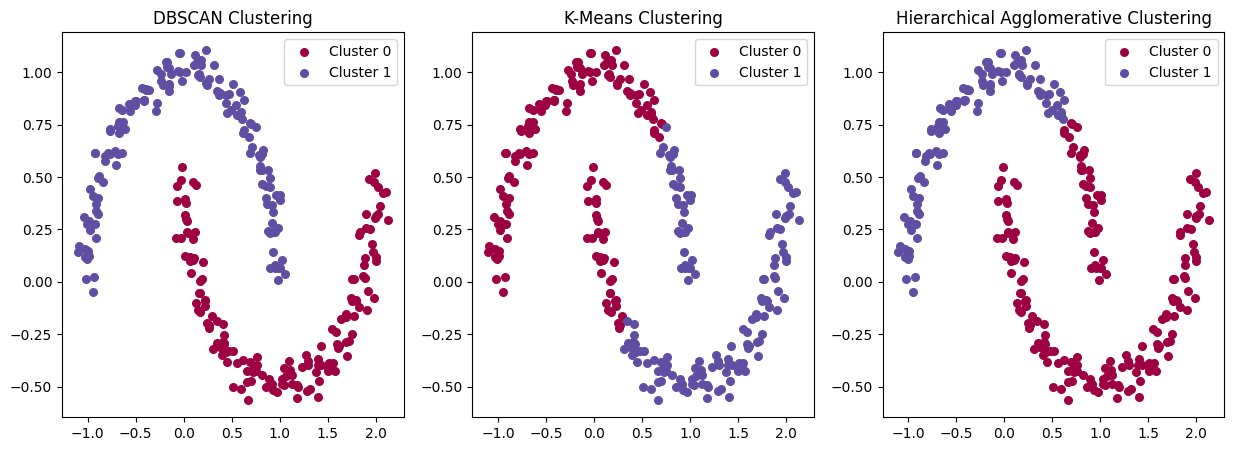

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.datasets import make_moons

# Generate synthetic data (you can replace this with your own data)
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Apply Hierarchical Agglomerative Clustering (HAC)
hac = AgglomerativeClustering(n_clusters=2)
hac_labels = hac.fit_predict(X)

# Plot the results for DBSCAN
plt.figure(figsize=(15, 5))

plt.subplot(131)
unique_labels_dbscan = np.unique(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels_dbscan)))

for label, color in zip(unique_labels_dbscan, colors):
    if label == -1:
        plt.scatter(X[dbscan_labels == label][:, 0], X[dbscan_labels == label][:, 1], color='gray', s=10, label='Noise')
    else:
        plt.scatter(X[dbscan_labels == label][:, 0], X[dbscan_labels == label][:, 1], color=color, s=30, label=f'Cluster {label}')

plt.title('DBSCAN Clustering')
plt.legend()

# Plot the results for K-Means
plt.subplot(132)
unique_labels_kmeans = np.unique(kmeans_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels_kmeans)))

for label, color in zip(unique_labels_kmeans, colors):
    plt.scatter(X[kmeans_labels == label][:, 0], X[kmeans_labels == label][:, 1], color=color, s=30, label=f'Cluster {label}')

plt.title('K-Means Clustering')
plt.legend()

# Plot the results for HAC
plt.subplot(133)
unique_labels_hac = np.unique(hac_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels_hac)))

for label, color in zip(unique_labels_hac, colors):
    plt.scatter(X[hac_labels == label][:, 0], X[hac_labels == label][:, 1], color=color, s=30, label=f'Cluster {label}')

plt.title('Hierarchical Agglomerative Clustering')
plt.legend()

plt.show()

Bài tập tự thực hành. Bài 2.1

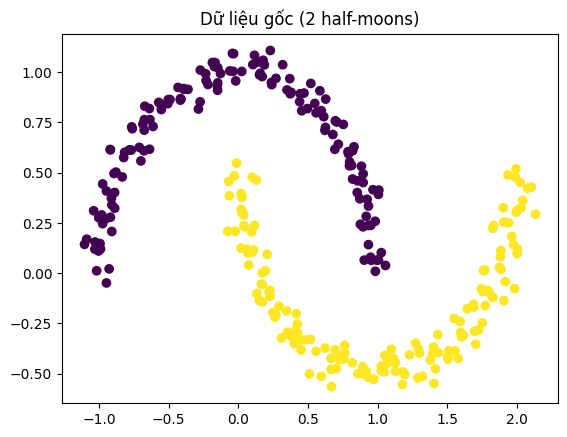

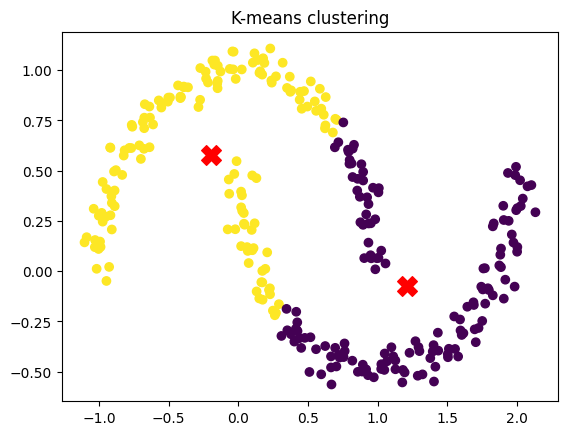

In [55]:
# Thực hiện phân cụm bằng phương pháp K-means với dữ liệu tạo ra trong ví dụ 2.1

# Tạo dữ liệu
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# tạo dữ liệu
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

plt.scatter(X[:,0], X[:,1], c=_, cmap='viridis')
plt.title("Dữ liệu gốc (2 half-moons)")
plt.show()

# Sử dụng K-Means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0)
y_kmeans = kmeans.fit_predict(X)

# Hiển thị kết quả
plt.scatter(X[:,0], X[:,1], c=y_kmeans, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            c='red', s=200, marker='X')
plt.title("K-means clustering")
plt.show()

Bài tập tự thực hành. Bài 2.2

In [56]:
# Đọc dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/Sales_Transactions_Dataset_Weekly.csv')
print(df.shape)
df.head()

(811, 107)


,Product_Code,W0,W1,W2,W3,W4,W5,W6,W7,W8,...,Normalized 42,Normalized 43,Normalized 44,Normalized 45,Normalized 46,Normalized 47,Normalized 48,Normalized 49,Normalized 50,Normalized 51
0,P1,11,12,10,8,13,12,14,21,6,...,0.06,0.22,0.28,0.39,0.50,0.00,0.22,0.17,0.11,0.39
1,P2,7,6,3,2,7,1,6,3,3,...,0.20,0.40,0.50,0.10,0.10,0.40,0.50,0.10,0.60,0.00
2,P3,7,11,8,9,10,8,7,13,12,...,0.27,1.00,0.18,0.18,0.36,0.45,1.00,0.45,0.45,0.36
3,P4,12,8,13,5,9,6,9,13,13,...,0.41,0.47,0.06,0.12,0.24,0.35,0.71,0.35,0.29,0.35
4,P5,8,5,13,11,6,7,9,14,9,...,0.27,0.53,0.27,0.60,0.20,0.20,0.13,0.53,0.33,0.40


In [57]:
# Bỏ cột không cần thiết
X = df.iloc[:, 1:53].values
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

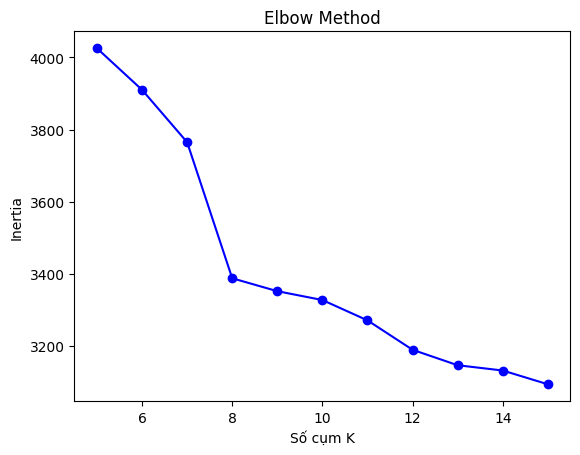

In [58]:
# Tìm k tối ưu (elbow)
inertia = []
K_range = range(5, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, 'bo-')
plt.xlabel("Số cụm K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
# Chọn K = 8

In [59]:
K_opt = 8

kmeans = KMeans(n_clusters=K_opt, random_state=0)
labels = kmeans.fit_predict(X_scaled)

print("Số cụm:", K_opt)

Số cụm: 8


In [60]:
# Gắn cụm vào dữ liệu
df["Cluster"] = labels
df.head()

,Product_Code,W0,W1,W2,W3,W4,W5,W6,W7,W8,...,Normalized 43,Normalized 44,Normalized 45,Normalized 46,Normalized 47,Normalized 48,Normalized 49,Normalized 50,Normalized 51,Cluster
0,P1,11,12,10,8,13,12,14,21,6,...,0.22,0.28,0.39,0.50,0.00,0.22,0.17,0.11,0.39,6
1,P2,7,6,3,2,7,1,6,3,3,...,0.40,0.50,0.10,0.10,0.40,0.50,0.10,0.60,0.00,3
2,P3,7,11,8,9,10,8,7,13,12,...,1.00,0.18,0.18,0.36,0.45,1.00,0.45,0.45,0.36,6
3,P4,12,8,13,5,9,6,9,13,13,...,0.47,0.06,0.12,0.24,0.35,0.71,0.35,0.29,0.35,6
4,P5,8,5,13,11,6,7,9,14,9,...,0.53,0.27,0.60,0.20,0.20,0.13,0.53,0.33,0.40,6


In [61]:
# Thống kê cụm
print(df["Cluster"].value_counts())

Cluster
0    303
3    187
6    114
1     72
5     45
2     42
4     34
7     14
Name: count, dtype: int64


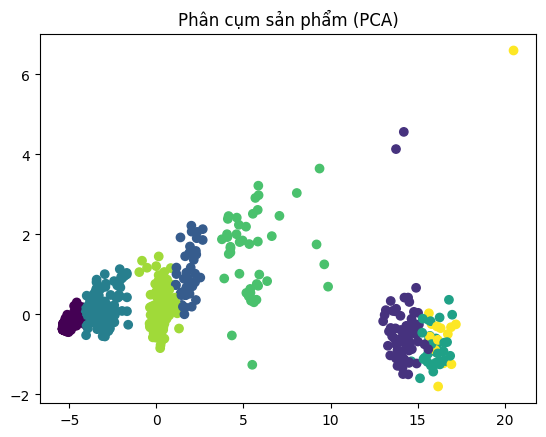

In [62]:
# Giảm chiều để vẽ
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')
plt.title("Phân cụm sản phẩm (PCA)")
plt.show()